
Bước 3: Hiểu đặc trưng (Feature Understanding)

Thực hiện EDA (Exploratory Data Analysis) bằng trực quan hóa:

Univariate (1 biến)

Bivariate (2 biến)

Multivariate (nhiều biến)

In [4]:
import pandas as pd
data = pd.read_csv('/home/vophilong/Documents/Deep_learning/Dataset/dataset.csv')

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách đồ thị chung
sns.set_theme(style="whitegrid")

#### UNIVARIATE ANALYSIS (Phân phối đơn biến)

1. Đang vẽ biểu đồ Univariate Analysis...


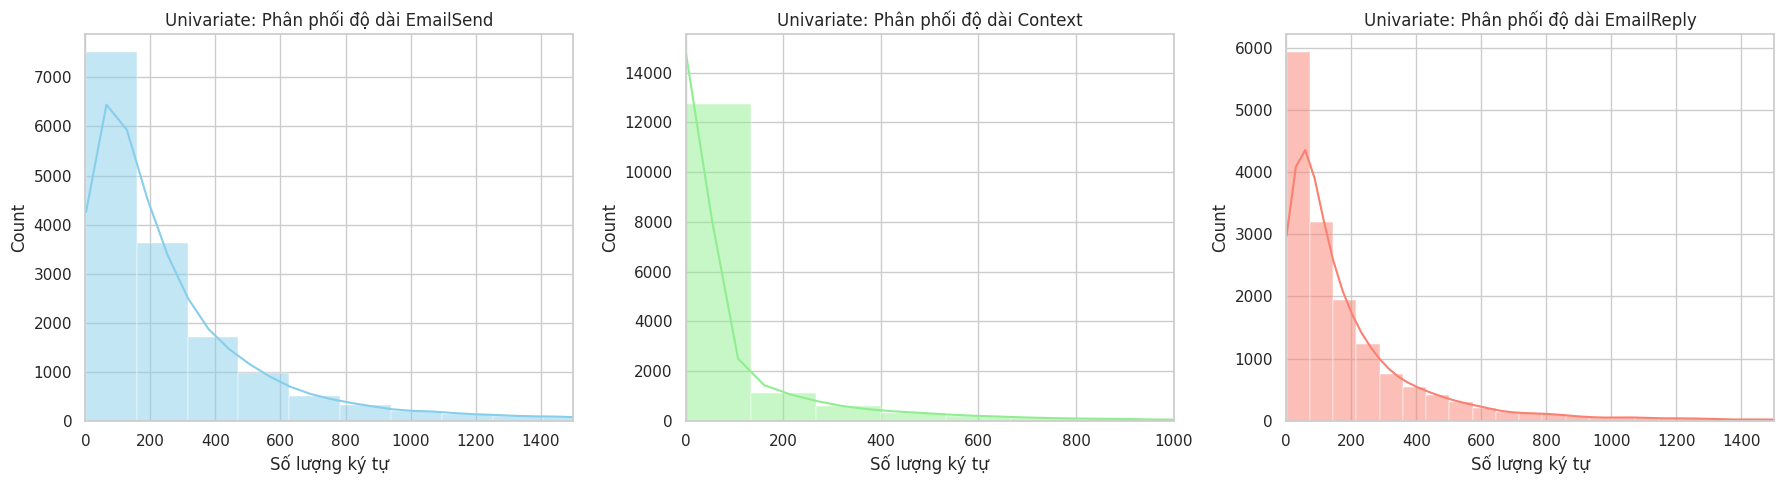

In [13]:
# Thiết lập phong cách đồ thị
sns.set_theme(style="whitegrid")

print("1. Đang vẽ biểu đồ Univariate Analysis...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tính trực tiếp độ dài và đưa thẳng vào đồ thị
sns.histplot(data['EmailSend'].astype(str).apply(len), bins=80, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Univariate: Phân phối độ dài EmailSend')
axes[0].set_xlabel('Số lượng ký tự')
axes[0].set_xlim(0, 1500) 

sns.histplot(data['Context'].fillna("").apply(len), bins=80, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Univariate: Phân phối độ dài Context')
axes[1].set_xlabel('Số lượng ký tự')
axes[1].set_xlim(0, 1000)

sns.histplot(data['EmailReply'].astype(str).apply(len), bins=80, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Univariate: Phân phối độ dài EmailReply')
axes[2].set_xlabel('Số lượng ký tự')
axes[2].set_xlim(0, 1500)

plt.tight_layout()
plt.show()

BIVARIATE ANALYSIS (Tương quan song biến)

2. Đang vẽ biểu đồ Bivariate Analysis...


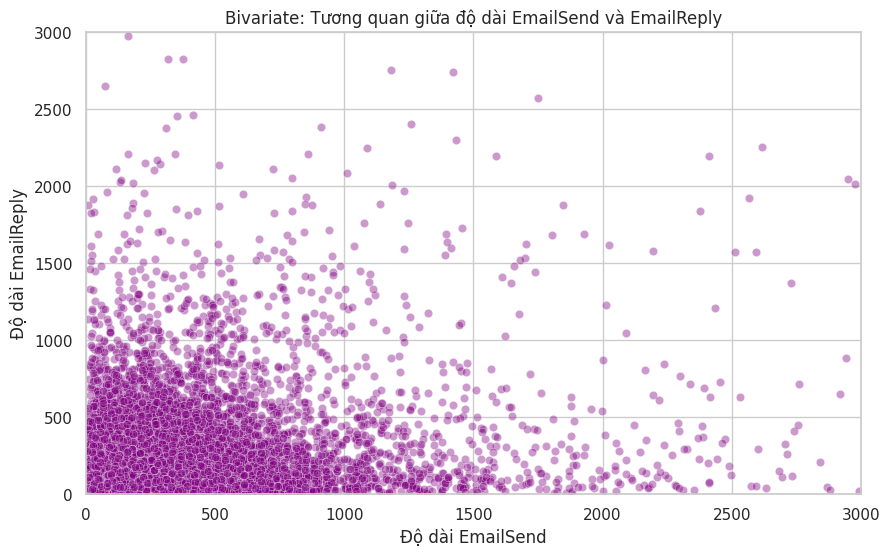

In [15]:
print("2. Đang vẽ biểu đồ Bivariate Analysis...")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=data['EmailSend'].astype(str).apply(len), 
    y=data['EmailReply'].astype(str).apply(len), 
    alpha=0.4, color='purple'
)
plt.title('Bivariate: Tương quan giữa độ dài EmailSend và EmailReply')
plt.xlabel('Độ dài EmailSend')
plt.ylabel('Độ dài EmailReply')
plt.xlim(0, 3000)
plt.ylim(0, 3000)
plt.show()

MULTIVARIATE ANALYSIS (Đa biến - Heatmap)

3. Đang vẽ biểu đồ Multivariate Analysis (Heatmap)...


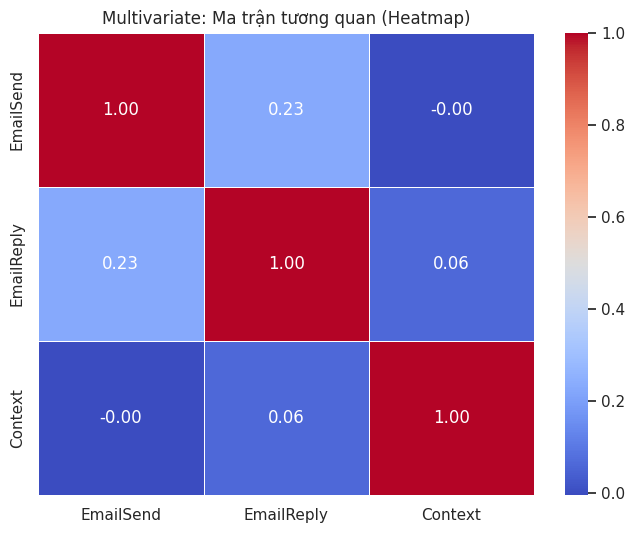

In [16]:
print("3. Đang vẽ biểu đồ Multivariate Analysis (Heatmap)...")
plt.figure(figsize=(8, 6))

# Ghép tạm 3 chuỗi độ dài thành một bảng trung gian nhỏ (chỉ lưu trên RAM) để tính ma trận tương quan, 
# cách này đảm bảo không làm thay đổi dataset gốc của bạn
temp_corr_df = pd.DataFrame({
    'EmailSend': data['EmailSend'].astype(str).apply(len),
    'EmailReply': data['EmailReply'].astype(str).apply(len),
    'Context': data['Context'].fillna("").apply(len)
})

sns.heatmap(temp_corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Multivariate: Ma trận tương quan (Heatmap)')
plt.show()